In [1]:
import pandas as pd

In [14]:
X_= pd.read_csv(r'D:\code\python\人工智慧原理\hw1_dataset\Problem 1\Averaged homework scores.csv', header=None)
Y_= pd.read_csv(r'D:\code\python\人工智慧原理\hw1_dataset\Problem 1\Final exam scores.csv', header=None)

In [15]:
X_

,0
0,97
1,84
2,76
3,82
4,74
...,...
495,92
496,97
497,90
498,72


In [16]:
Y_

,0
0,98
1,87
2,84
3,90
4,83
...,...
495,88
496,97
497,100
498,83


In [17]:
import numpy as np
import pandas as pd

In [18]:
X= np.array(X_)
Y= np.array(Y_)

In [19]:
len(X)

500

In [20]:
np.random.seed(42)
indices= np.arange(len(X))
np.random.shuffle(indices)
X_shuffled= X[indices]
Y_shuffled= Y[indices]

In [24]:
X_train, Y_train= X_shuffled[:400], Y_shuffled[:400]
X_test, Y_test= X_shuffled[400:], Y_shuffled[400:]

In [86]:
"""
X_min, X_max = X_train.min(), X_train.max()
Y_min, Y_max = Y_train.min(), Y_train.max()

X_train_norm = (X_train - X_min) / (X_max - X_min)
Y_train_norm = (Y_train - Y_min) / (Y_max - Y_min)

X_test_norm = (X_test - X_min) / (X_max - X_min)
Y_test_norm = (Y_test - Y_min) / (Y_max - Y_min)
"""

X_train_norm= X_train/100
Y_train_norm= Y_train/100
X_test_norm= X_test/100
Y_test_norm= Y_test/100



In [87]:
#initalize
w= np.random.rand(1)
b= np.random.rand(1)
lr=0.01
T=1000

In [ ]:
# SGD
for t in range(T):
    rand_index= np.random.randint(0, len(X_train_norm))
    x_i= X_train_norm[rand_index]
    y_i= Y_train_norm[rand_index]
    y_pred= w*x_i + b
    error= y_i-y_pred  
    grad_w= -2*x_i*error 
    grad_b= -2*error
    w= w - lr*grad_w
    b= b - lr*grad_b

In [96]:
Y_test_pred_norm = w * X_test_norm + b
Y_test_pred = Y_test_pred_norm * 100
mse = np.mean((Y_test - Y_test_pred) ** 2)


In [97]:
mse

17.817531883215725

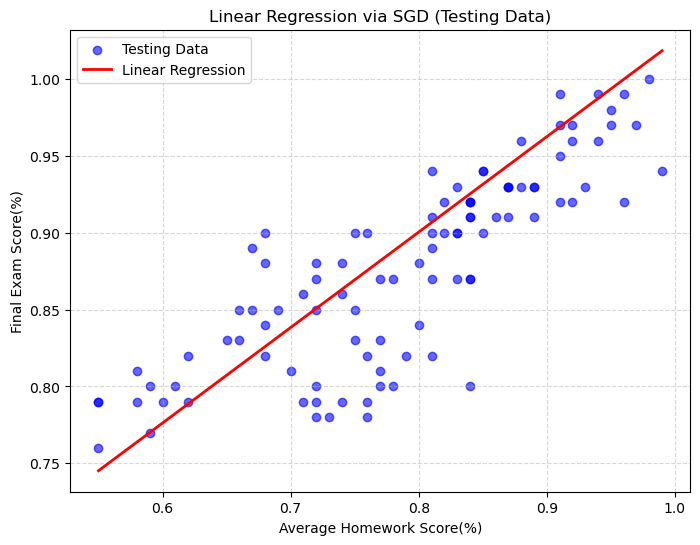

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))



X_test_norm = X_test/100
Y_test_norm = Y_test/100
# 畫出 100 筆測試資料的散佈圖
plt.scatter(X_test_norm, Y_test_norm, color='blue', alpha=0.6, label='Testing Data')

# 畫出迴歸線 (取測試集的最小值與最大值來畫線)
x_line = np.array([X_test_norm.min(), X_test_norm.max()])
y_line_norm = w * x_line + b
y_line = y_line_norm 

plt.plot(x_line, y_line, color='red', linewidth=2, label='Linear Regression')

# 圖表設定
plt.title("Linear Regression via SGD (Testing Data)")
plt.xlabel("Average Homework Score(%)")
plt.ylabel("Final Exam Score(%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 顯示圖表
plt.show()

In [100]:
import pandas as pd
import numpy as np
X1_= pd.read_csv(r'D:\code\python\人工智慧原理\hw1_dataset\Problem 2\Averaged homework scores.csv', header=None)
X2_= pd.read_csv(r'D:\code\python\人工智慧原理\hw1_dataset\Problem 2\Final exam scores.csv', header=None)
Y_= pd.read_csv(r'D:\code\python\人工智慧原理\hw1_dataset\Problem 2\Results.csv', header=None)

In [104]:
X= np.column_stack((X1_, X2_))
Y= np.array(Y_)

In [105]:
indices= np.arange(len(X))
np.random.shuffle(indices)
X_shuffled= X[indices]
Y_shuffled= Y[indices]

In [106]:
X_train, Y_train= X_shuffled[:400], Y_shuffled[:400]
X_test, Y_test= X_shuffled[400:], Y_shuffled[400:]


In [107]:
X_train_mean= X_train.mean(axis=0)
X_train_std= X_train.std(axis=0)
X_train_norm= (X_train - X_train_mean) / X_train_std


In [136]:
X_test_norm = (X_test - X_train_mean) / X_train_std

In [118]:
def sigmoid(z):
    # 使用 np.clip 避免 exp 內數字過大導致 overflow
    z = np.clip(z, -250, 250)
    return 1.0 / (1.0 + np.exp(-z))

In [132]:
w= np.random.rand(2, 1)
b= np.random.rand(1)
lr=0.75
T=1000

In [ ]:
for t in range(T):
    index= np.random.randint(0, len(X_train_norm))
    x_i= X_train_norm[index]
    y_i= Y_train[index]
    z= np.dot(x_i, w) + b
    y_pred= sigmoid(z)
    error= y_i - y_pred
    grand_w=error*x_i
    grand_b=error
    w=w-lr*grand_w.reshape(2, 1)
    b=b-lr*grand_b


In [138]:
Z_test_norm= np.dot(X_test_norm, w) + b
Y_test_pred= sigmoid(Z_test_norm)
epsilon = 1e-15
Y_test_pred = np.clip(Y_test_pred, epsilon, 1 - epsilon)
logistic_loss=np.mean(-Y_test * np.log(Y_test_pred) - (1 - Y_test) * np.log(1 - Y_test_pred))


In [139]:
logistic_loss

27.715315279910627

In [151]:
Y_test

array([[0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
    

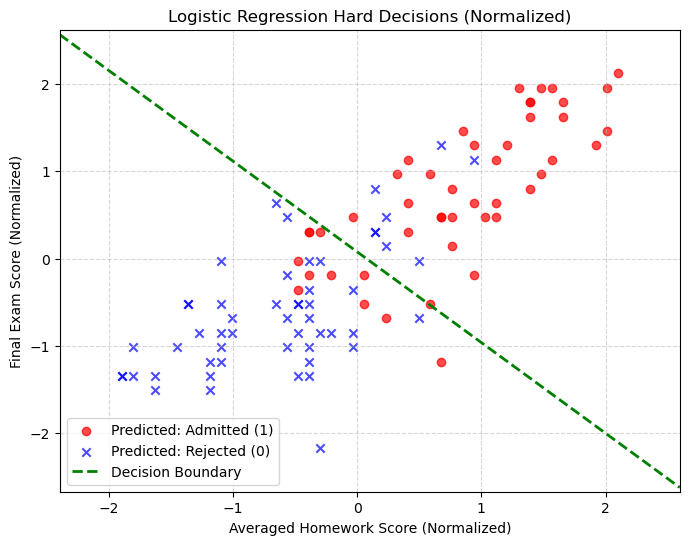

In [154]:

Y_test=  Y_test.reshape(-1)
plt.figure(figsize=(8, 6))

# 畫出預測為"錄取"的點 (紅色圓圈)
plt.scatter(X_test_norm[Y_test == 1][:, 0], 
            X_test_norm[Y_test == 1][:, 1], 
            color='red', label='Predicted: Admitted (1)', alpha=0.7)

# 畫出預測為"未錄取"的點 (藍色叉叉)
plt.scatter(X_test_norm[Y_test == 0][:, 0], 
            X_test_norm[Y_test == 0][:, 1], 
            color='blue', marker='x', label='Predicted: Rejected (0)', alpha=0.7)

# 畫出決策邊界 (Decision Boundary)
# 公式: x2 = -(w[0]/w[1]) * x1 - b/w[1]
x_vals = np.array([X_test_norm[:, 0].min() - 0.5, X_test_norm[:, 0].max() + 0.5])
# 確保 w[1] 不為 0 以避免除以零錯誤
if w[1] != 0:
    y_vals = -(w[0] / w[1]) * x_vals - (b / w[1])
    plt.plot(x_vals, y_vals, '--', color='green', linewidth=2, label='Decision Boundary')

plt.title("Logistic Regression Hard Decisions (Normalized)")
plt.xlabel("Averaged Homework Score (Normalized)")
plt.ylabel("Final Exam Score (Normalized)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 設定座標軸範圍，讓圖表更好看
plt.xlim(X_test_norm[:, 0].min() - 0.5, X_test_norm[:, 0].max() + 0.5)
plt.ylim(X_test_norm[:, 1].min() - 0.5, X_test_norm[:, 1].max() + 0.5)

plt.show()

In [149]:
np.shape(Y_test_pred_hard.reshape(-1))

(100,)